# Running before test

In [42]:
%load_ext autoreload
%autoreload 2
import sys 
sys.path.append("../lib")
import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)
jax.config.update("jax_platform_name", "cpu")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [43]:
import matplotlib.pyplot as plt
params = {
    'axes.labelsize': 20,
    'font.size': 20,
    'lines.linewidth': 2,
    'legend.fontsize': 18,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'text.usetex': True,
    'figure.figsize': [15, 6],
    'axes.linewidth': 1.5
}
plt.rcParams.update(params)

def plot_map(map,xi1=None,xi2=None,vmax=None,vmin=None,extend=None):
    plt.figure(figsize=(8, 6))
    if extend is None and xi1 is not None and xi2 is not None:
        extend = [xi1.min(), xi1.max(), xi2.min(), xi2.max()]
    elif extend is None :
        extend = [0, map.shape[1], 0, map.shape[0]]
    plt.imshow(map, origin='lower', cmap='viridis', extent=extend, vmax=vmax, vmin=vmin)
    plt.colorbar()

    plt.xlabel("X (grid index)")
    plt.ylabel("Y (grid index)")
    plt.show()


In [206]:

from SIDM_Parametric_Model_jax import SIDM_parametric
from lenstronomy.Cosmo.nfw_param import NFWParam
from Lensing_tool import Da0, make_c_coor, alphas_to_mu
from astropy.cosmology import FlatwCDM
import numpy as np

# Initialize cosmology and parameters
cosmo = FlatwCDM(H0=70.0, Om0=0.3, Ob0=0.05, w0=-1.000000)
nfwpara = NFWParam(cosmo)

zlens = 0.439
zsource = 3
apr = 1.0 / np.pi * 180.0 * 3600  # arcsec per rad

Mass_main = 5e15  # Msun

# NFW parameters for main halo
r200_main, rhos_main, Concentration_main, rs_main = nfwpara.nfw_Mz(Mass_main, zlens)

Da_zlens = Da0(zlens)
rs_arc_sidm = rs_main / Da_zlens * apr  # Convert to arcsec

Mass_sub = 1e13  # Msun

# NFW parameters for subhalo
r200_sub, rhos_sub, Concentration_sub, rs_sub = nfwpara.nfw_Mz(Mass_sub, zlens)

# Distances to iterate over
distance = 0.25

thetaE = 58.4598

halos = []

# Main halo
mainhalo = {
    'mass': Mass_main,
    'tnfw_params': {
        'rs': rs_main,
        'rhos': rhos_main
    },
    'redshift': zlens,
    'tau': 0,
    'position_x': 0,
    'position_y': 0
}
halos.append(mainhalo)

# Subhalo1
subhalo = {
    'mass': Mass_sub,
    'tnfw_params': {
        'rs': rs_sub,
        'rhos': rhos_sub
    },
    'redshift': zlens,
    'tau': 1.08,
    'position_x': rs_arc_sidm * distance,
    'position_y': 0
}
halos.append(subhalo)

# Global box size and grid setup
bsz_arc = rs_arc_sidm
nnn = 4000
dsx_arc = bsz_arc / nnn
xi2, xi1 = make_c_coor(bsz_arc, nnn)

# SIDM model for global view
sidm_model_global = SIDM_parametric(tnfw_params=halos, bsz_arc=bsz_arc, dsx_arc=dsx_arc, zsource=zsource)



# Using parametric

## kappa

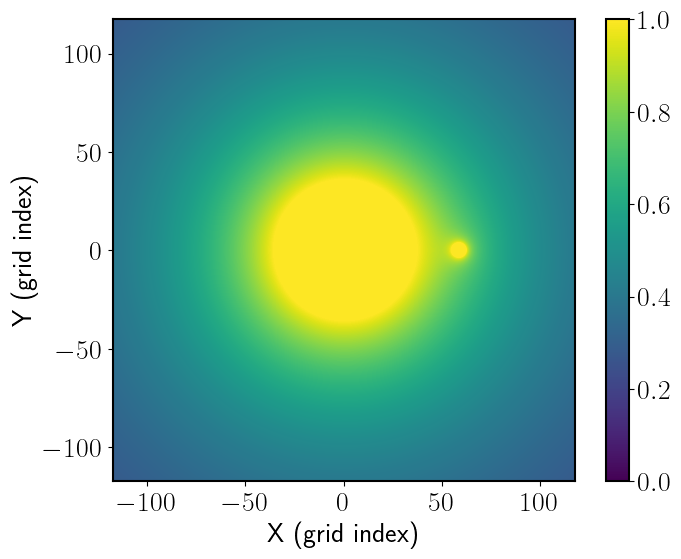

In [207]:
sidm_model_global.compute_kappa_map()
kappa_global = sidm_model_global._kappa_map
plot_map(kappa_global,xi1,xi2,vmax=1,vmin=0)

## Potential

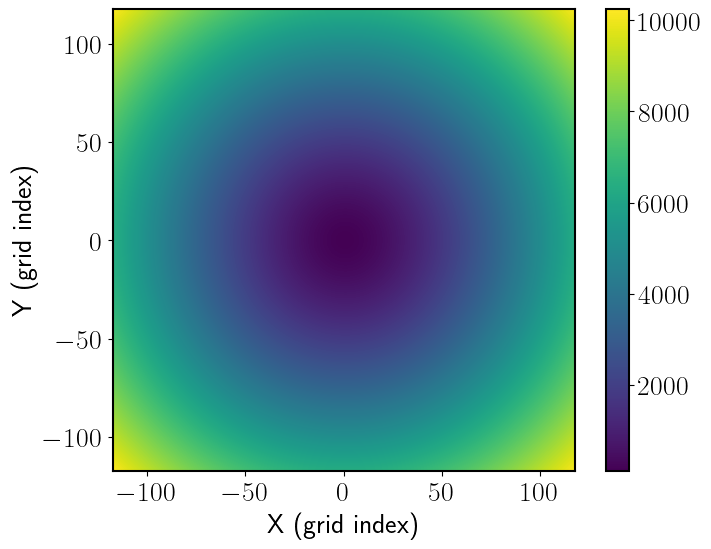

In [208]:
sidm_model_global.compute_potential_map()
plot_map(sidm_model_global._potential_map,xi1,xi2)

## alpha

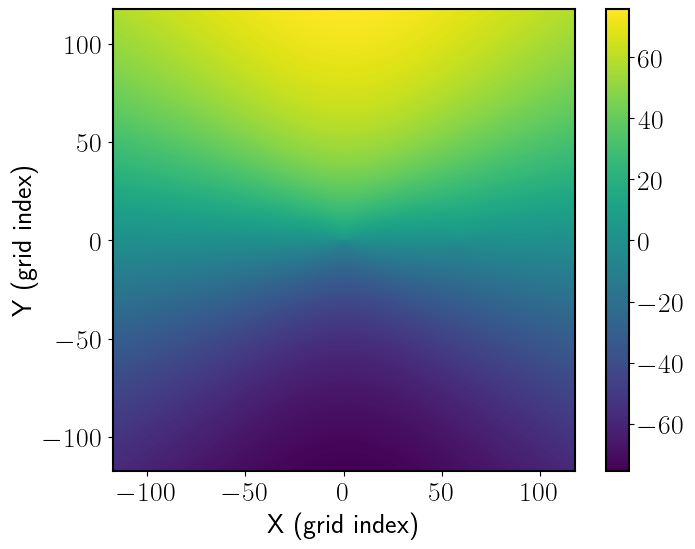

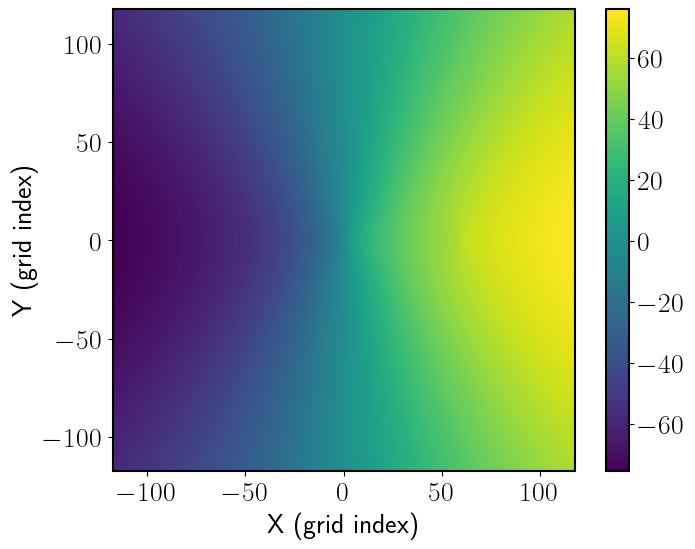

In [209]:
alpha1_global, alpha2_global = sidm_model_global.compute_alpha_map()

plot_map(alpha1_global,xi1,xi2)
plot_map(alpha2_global,xi1,xi2)

## Critical and Caustic

In [210]:
yi1, yi2, mu_global, kappa_, gamma1_gobal, gamma2_gobal = alphas_to_mu(alpha1_global, alpha2_global, dsx_arc, xi1, xi2)
gamma_global = np.sqrt(gamma1_gobal**2 + gamma2_gobal**2)
lambdat_global = 1 - kappa_global - gamma_global
lambdar_global = 1 - kappa_global + gamma_global

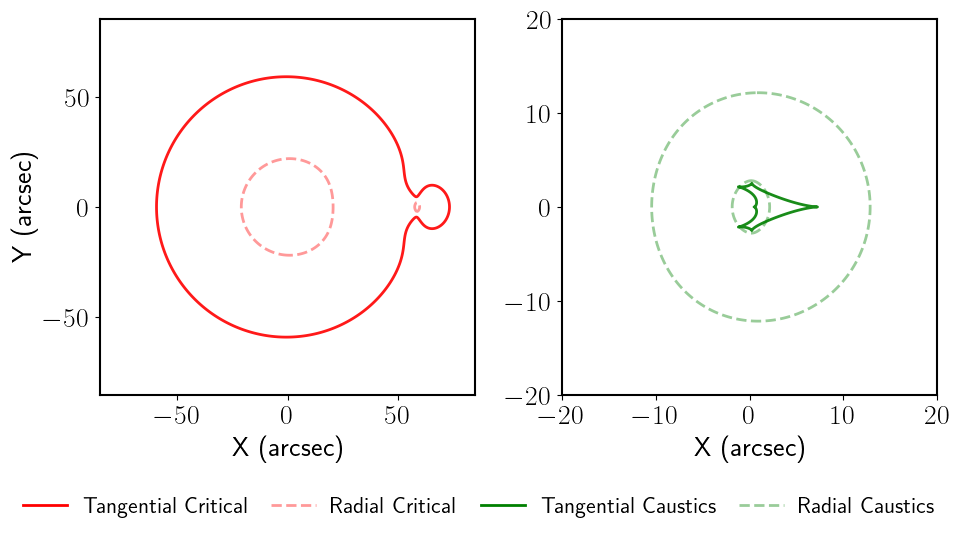

In [212]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# Assuming you have values for xi1, xi2, yi1, yi2, mu_global, lambdar_global, lambdat_global, etc.

fig_combined, ax = plt.subplots(1, 2, figsize=(10, 6))

# First subplot
ax_ = ax[0]

lambdar_contour1 = ax_.contour(xi2, xi1, lambdar_global, levels=[0.0], colors='red', linewidths=2, alpha=0.4, linestyles='dashed')
lambdat_contour1 = ax_.contour(xi2, xi1, lambdat_global, levels=[0.0], colors='red', linewidths=2, alpha=0.9, linestyles='-')

ax_.set_aspect('equal')
ax_.set_xlabel("X (arcsec)")
ax_.set_ylabel("Y (arcsec)")
ax_.set_xlim(-85, 85)
ax_.set_ylim(-85, 85)

# Second subplot
ax_ = ax[1]

lambdar_contour2 = ax_.contour(yi2, yi1, lambdar_global, levels=[0.0], colors='green', linewidths=2, alpha=0.4, linestyles='dashed')
lambdat_contour2 = ax_.contour(yi2, yi1, lambdat_global, levels=[0.0], colors='green', linewidths=2, alpha=0.9, linestyles='-')

ax_.set_aspect('equal')
ax_.set_xlabel("X (arcsec)")
# ax_.set_ylabel("Y (arcsec)")
ax_.set_xlim(-20,20)
ax_.set_ylim(-20,20)

# Create custom legend with only lines (no color blocks)
solid_line = mlines.Line2D([], [], color='red', linestyle='-', label='Tangential Critical')
dashed_line = mlines.Line2D([], [], color='red', linestyle='--', label='Radial Critical',alpha=0.4)
solid_line2 = mlines.Line2D([], [], color='green', linestyle='-', label='Tangential Caustics')
dashed_line2 = mlines.Line2D([], [], color='green', linestyle='--', label='Radial Caustics',alpha=0.4)

# Add legend to the figure
fig_combined.legend(handles=[solid_line, dashed_line, solid_line2, dashed_line2],
                    loc='upper center',  # Position the legend at the top
                    bbox_to_anchor=(0.5, 0.06),  # Positioning it below the plot
                    ncol=4,  # Number of columns in the legend
                    fontsize=16,  # Font size
                    frameon=False,  # Remove the frame around the legend
                    columnspacing=1.0,  # Adjust the spacing between columns
                    handletextpad=0.7)  # Adjust the spacing between the legend symbol and text

# Adjust layout and show plot
fig_combined.tight_layout()
plt.savefig("critical_curves.png")
plt.show()

# Using Fluid Simulation to Contrast

Input tr0: 0.001
Closest found tr: 0.00046415888336127773
Corresponding file: data_tr_0.00046415888336127773.pickle
Input tr0: 1.05
Closest found tr: 1.0510360069440001
Corresponding file: data_tr_1.0510360069440001.pickle


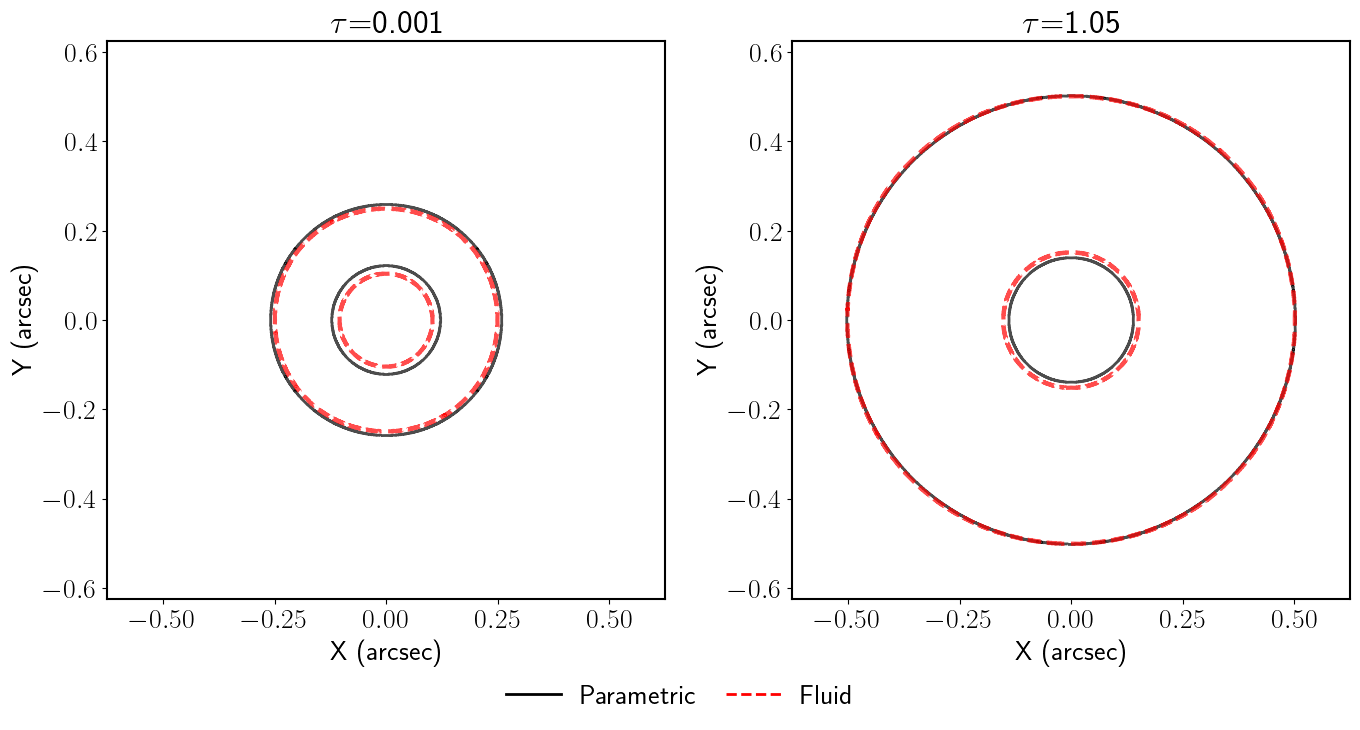

In [205]:
import matplotlib.pyplot as plt
from lenstronomy.Cosmo.nfw_param import NFWParam
from Lensing_tool import SigmaCrit, Da0, make_c_coor, alphas_to_mu,call_kappa_to_alphas
from astropy.cosmology import FlatwCDM
import numpy as np
from SIDM_density_fluid import refrence_Sigma
import pickle


# Initialize cosmology and parameters
cosmo = FlatwCDM(H0=70.0, Om0=0.3, Ob0=0.05, w0=-1.000000)
nfwpara = NFWParam(cosmo)

zlens = 0.439
zsource = 3
apr = 1.0 / np.pi * 180.0 * 3600  # arcsec per rad
Sigma_cr = SigmaCrit(zlens, zsource)
Mass_main = 5e15  # Msun
r200_main, rhos_main, Concentration_main, rs_main = nfwpara.nfw_Mz(Mass_main, zlens)
Da_zlens = Da0(zlens)
rs_arc_sidm = rs_main / Da_zlens * apr  # Convert to arcsec

taus = [0.001, 1.05]
# Prepare Figure 1: Global view
fig1, axes1 = plt.subplots(1, 2, figsize=(14, 8))


for i, tau in enumerate(taus):
    halos = []
    # Main halo
    mainhalo = {
        'mass': Mass_main,
        'tnfw_params': {
            'rs': rs_main,
            'rhos': rhos_main
        },
        'redshift': zlens,
        'tau': tau,
        'position_x': 0,
        'position_y': 0
    }
    halos.append(mainhalo)

    # Global box size and grid setup
    bsz_arc = rs_arc_sidm * 2.5
    # bsz_arc = 20
    nnn = 4000
    dsx_arc = bsz_arc / nnn
    xi2, xi1 = make_c_coor(bsz_arc, nnn)
    filename = f"$\\tau$={tau}"
    # save_coordizxnates(filename, xi2, xi1, nnn)

    # SIDM model for global view
    sidm_model_global = SIDM_parametric(tnfw_params=halos, bsz_arc=bsz_arc, dsx_arc=dsx_arc, zsource=zsource)
    alpha1_global, alpha2_global = sidm_model_global.compute_alpha_map()
    y1_global, y2_global, mu_global,_,_,_ = alphas_to_mu(alpha1_global, alpha2_global, dsx_arc, xi1, xi2)

    Sigma_global_an,tr_real = refrence_Sigma(tau,xi2,xi1,rs_main,rhos_main,zlens)
    kappa_global_main = Sigma_global_an / Sigma_cr
    
    kappa_global = kappa_global_main 

    alpha1_global_fft, alpha2_global_fft = call_kappa_to_alphas(kappa_global, bsz_arc, nnn, boundary_type='I')
    y1_global_fft, y2_global_fft, mu_global_fft, kappa_fft,gamma1_fft,gamma2_fft = alphas_to_mu(alpha1_global_fft, alpha2_global_fft, dsx_arc, xi1, xi2)

    # Crop parameters
    crop_factor = 0.5 # Crop 50% of the image
    center = nnn // 2  # Center of the image
    crop_size = int(nnn * crop_factor / 2)  # Half of the crop size

    # 确定裁剪范围
    x_min, x_max = center - crop_size, center + crop_size
    y_min, y_max = center - crop_size, center + crop_size

    # 裁剪网格和数据
    xi1_crop = xi1[x_min:x_max, y_min:y_max]
    xi2_crop = xi2[x_min:x_max, y_min:y_max]
    mu_sub_crop = mu_global[x_min:x_max, y_min:y_max]
    mu_global_fft_crop = mu_global_fft[x_min:x_max, y_min:y_max]

    # Plot on the corresponding subplot
    ax = axes1[i]
    ax.contour(xi2_crop / rs_arc_sidm, xi1_crop / rs_arc_sidm, mu_sub_crop, colors='k', linewidths=2, alpha=0.7)
    ax.contour(xi2_crop / rs_arc_sidm, xi1_crop / rs_arc_sidm, mu_global_fft_crop, colors='r', linestyles='--', linewidths=3, alpha=0.7)
    ax.set_title(filename)
    ax.set_aspect('equal')
    ax.set_xlabel("X (arcsec)")
    ax.set_ylabel("Y (arcsec)")


# Create custom legend with only lines (no color blocks)
dashed_line = mlines.Line2D([], [], color='red', linestyle='--', label='Fluid')
solid_line = mlines.Line2D([], [], color='black', linestyle='-', label='Parametric')

# Add legend to the figure
fig1.legend(handles=[solid_line, dashed_line],
                    loc='upper center',  # Position the legend at the top
                    bbox_to_anchor=(0.5, 0.08),  # Positioning it below the plot
                    ncol=2,  # Number of columns in the legend
                    fontsize=20,  # Font size
                    frameon=False,  # Remove the frame around the legend
                    columnspacing=1.0,  # Adjust the spacing between columns
                    handletextpad=0.7)  # Adjust the spacing between the legend symbol and text

# Adjust layout and show
fig1.tight_layout()


plt.show()